# Lab 11 — Phase 4: DL-SCA on ASCON-128 (Variable-Key Attack)

**CS-360 Cyber Security | BSCS-2K23 | Spring 2026**

> **Setup:** Runtime → Change runtime type → **T4 GPU** <br>
**Ahmad Hassan Tanveer | CMS ID 457627 | BSCS13C | Cyber Group 2**

In [5]:
# ── Load dataset from Google Drive ────────────────────────
from google.colab import drive
drive.mount('/content/drive')
H5_PATH = '/content/drive/MyDrive/variable_key_traces.h5'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# ── Imports ────────────────────────────────────────────────
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import os

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
# ── Load dataset ───────────────────────────────────────────
with h5py.File(H5_PATH, 'r') as f:
    x_prof  = f['profiling/traces'][:]    # (40000, 1000)
    y_prof  = f['profiling/labels'][:]    # (40000,)
    n_prof  = f['profiling/plaintexts'][:] # nonces
    k_prof  = f['profiling/keys'][:]      # profiling keys
    x_atk   = f['attack/traces'][:]       # (10000, 1000)
    y_atk   = f['attack/labels'][:]       # (10000,)
    n_atk   = f['attack/plaintexts'][:]   # nonces
    k_atk   = f['attack/keys'][:]         # per-trace attack keys

TRACE_LEN = x_prof.shape[1]
print(f'Profiling : {x_prof.shape}  labels: {np.unique(y_prof, return_counts=True)}')
print(f'Attack    : {x_atk.shape}   labels: {np.unique(y_atk,  return_counts=True)}')
print(f'Profiling key[0]: {bytes(k_prof[0]).hex()}')
print(f'Attack    key[0]: {bytes(k_atk[0]).hex()}')

Profiling : (40000, 1000)  labels: (array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=uint8), array([  139,  1257,  4580,  8730, 10800,  8713,  4350,  1249,   182]))
Attack    : (10000, 1000)   labels: (array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=uint8), array([  47,  323, 1115, 2219, 2719, 2120, 1087,  326,   44]))
Profiling key[0]: f581c1902d83f1f8f79d5091a649f68d
Attack    key[0]: a2ba88c4f5262690b9992b41dae13a61


In [8]:
# ── Normalize (StandardScaler fit on profiling set) ────────
scaler = StandardScaler()
x_prof_n = scaler.fit_transform(x_prof).astype(np.float32)
x_atk_n  = scaler.transform(x_atk).astype(np.float32)

# Add channel dim for Conv1D  → (N, 1000, 1)
x_prof_n = x_prof_n[..., np.newaxis]
x_atk_n  = x_atk_n[..., np.newaxis]
print('Normalised shapes:', x_prof_n.shape, x_atk_n.shape)

Normalised shapes: (40000, 1000, 1) (10000, 1000, 1)


In [9]:
# ── Model ──────────────────────────────────────────────────
def build_model(trace_len):
    inp = layers.Input(shape=(trace_len, 1))
    x = layers.Conv1D(64, 11, activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.AveragePooling1D(2)(x)
    x = layers.Conv1D(128, 11, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.AveragePooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(9, activation='softmax')(x)
    return models.Model(inp, out)

model = build_model(TRACE_LEN)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1000, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1000, 64)       │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 500, 64)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 500, 128)       │        90,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 500, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 250, 128)       │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,192,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,318,089 (31.73 MB)

 Trainable params: 8,317,705 (31.73 MB)

 Non-trainable params: 384 (1.50 KB)

In [10]:
# ── Train ──────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cb = [
    callbacks.ModelCheckpoint('model_variable_key.h5', save_best_only=True,
                               monitor='val_accuracy', verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=5, verbose=1)
]

history = model.fit(
    x_prof_n, y_prof,
    validation_split=0.1,
    epochs=50,
    batch_size=256,
    callbacks=cb,
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.2488 - loss: 1.9686
Epoch 1: val_accuracy improved from None to 0.26100, saving model to model_variable_key.h5



Epoch 1: finished saving model to model_variable_key.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 28s 136ms/step - accuracy: 0.2694 - loss: 1.8054 - val_accuracy: 0.2610 - val_loss: 1.8863 - learning_rate: 0.0010
Epoch 2/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3116 - loss: 1.6385
Epoch 2: val_accuracy improved from 0.26100 to 0.26175, saving model to model_variable_key.h5



Epoch 2: finished saving model to model_variable_key.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.3086 - loss: 1.6410 - val_accuracy: 0.2618 - val_loss: 1.7861 - learning_rate: 0.0010
Epoch 3/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3449 - loss: 1.5541
Epoch 3: val_accuracy improved from 0.26175 to 0.28500, saving model to model_variable_key.h5



Epoch 3: finished saving model to model_variable_key.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.3404 - loss: 1.5650 - val_accuracy: 0.2850 - val_loss: 1.6624 - learning_rate: 0.0010
Epoch 4/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3886 - loss: 1.4608
Epoch 4: val_accuracy improved from 0.28500 to 0.30175, saving model to model_variable_key.h5



Epoch 4: finished saving model to model_variable_key.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.3813 - loss: 1.4758 - val_accuracy: 0.3018 - val_loss: 1.6107 - learning_rate: 0.0010
Epoch 5/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4445 - loss: 1.3389
Epoch 5: val_accuracy improved from 0.30175 to 0.30500, saving model to model_variable_key.h5



Epoch 5: finished saving model to model_variable_key.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.4353 - loss: 1.3630 - val_accuracy: 0.3050 - val_loss: 1.6361 - learning_rate: 0.0010
Epoch 6/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5088 - loss: 1.2080
Epoch 6: val_accuracy did not improve from 0.30500
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.4959 - loss: 1.2365 - val_accuracy: 0.2945 - val_loss: 1.6674 - learning_rate: 0.0010
Epoch 7/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5685 - loss: 1.0664
Epoch 7: val_accuracy did not improve from 0.30500
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.5587 - loss: 1.0909 - val_accuracy: 0.2960 - val_loss: 1.7325 - learning_rate: 0.0010
Epoch 8/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6185 - loss: 0.9469
Epoch 8: val_accuracy did not improve from 0.30500
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.6087 - loss: 0.9719 - val_accuracy: 0.2990 - va


Epoch 16: finished saving model to model_variable_key.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.8617 - loss: 0.3493 - val_accuracy: 0.3052 - val_loss: 2.5144 - learning_rate: 2.5000e-04
Epoch 17/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8697 - loss: 0.3246
Epoch 17: val_accuracy did not improve from 0.30525
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.8705 - loss: 0.3232 - val_accuracy: 0.2950 - val_loss: 2.6139 - learning_rate: 2.5000e-04
Epoch 18/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8801 - loss: 0.3058
Epoch 18: val_accuracy did not improve from 0.30525
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.8779 - loss: 0.3077 - val_accuracy: 0.2948 - val_loss: 2.7423 - learning_rate: 2.5000e-04
Epoch 19/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8875 - loss: 0.2869
Epoch 19: val_accuracy did not improve from 0.30525

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
141/14

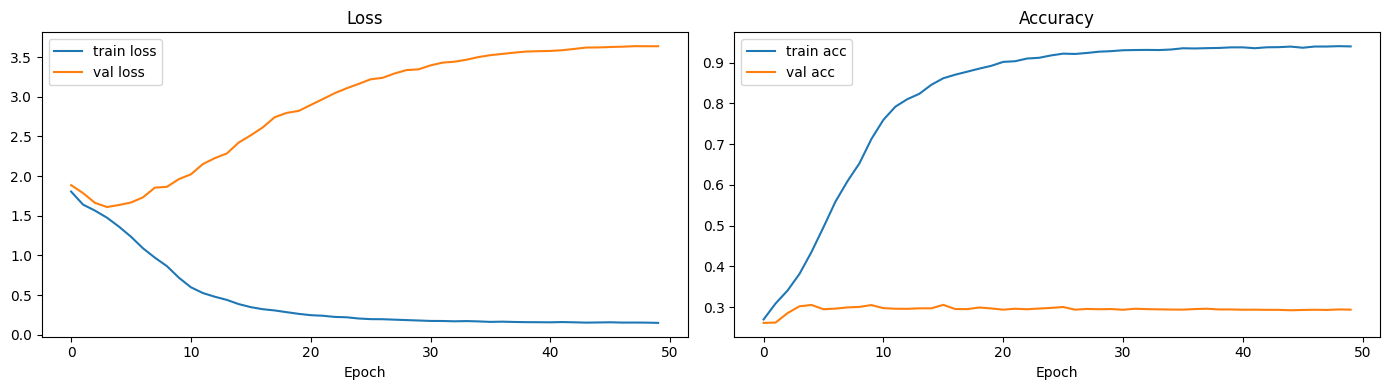

Saved: training_curves_variable.png


In [11]:
# ── Training curves ────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history.history['loss'],     label='train loss')
ax1.plot(history.history['val_loss'], label='val loss')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history.history['accuracy'],     label='train acc')
ax2.plot(history.history['val_accuracy'], label='val acc')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.savefig('training_curves_variable.png', dpi=150)
plt.show()
print('Saved: training_curves_variable.png')

In [12]:
# ── Evaluate on attack set ─────────────────────────────────
model.load_weights('model_variable_key.h5')
loss, acc = model.evaluate(x_atk_n, y_atk, verbose=0)
print(f'Attack-set accuracy: {acc*100:.2f}%   loss: {loss:.4f}')

Attack-set accuracy: 30.30%   loss: 2.4818


In [13]:
# ── ASCON S-box HW lookup table ────────────────────────────
def _ascon_sbox_byte(x0, x1, x2, x3, x4):
    """Apply ASCON S-box to a single column (5 single-bit inputs)."""
    x0 ^= x4; x4 ^= x3; x2 ^= x1
    t0,t1,t2,t3,t4 = x0,x1,x2,x3,x4
    x0 = t0^(~t1&t2); x1 = t1^(~t2&t3)
    x2 = t2^(~t3&t4); x3 = t3^(~t4&t0)
    x4 = t4^(~t0&t1)
    x1^=x0; x0^=x4; x3^=x2; x2=~x2
    return x0&1, x1&1, x2&1, x3&1, x4&1

def build_sbox_hw_table():
    table = np.zeros(256, dtype=np.uint8)
    for v in range(256):
        out_byte = 0
        for bit in range(8):
            b = (v >> bit) & 1
            _, _, x2_out, _, _ = _ascon_sbox_byte(0, 0, b, 0, 0)
            out_byte |= (x2_out << bit)
        table[v] = bin(out_byte).count('1')
    return table

SBOX_HW = build_sbox_hw_table()
print('S-box HW table (first 16):', SBOX_HW[:16])

S-box HW table (first 16): [8 7 7 6 7 6 6 5 7 6 6 5 6 5 5 4]


In [14]:
# ── Key rank analysis (key byte 0, using per-trace keys) ───
# In the variable-key setting the attack set uses different keys per trace.
# We pick one target trace index and its corresponding true key byte,
# then accumulate log-probs over the first N_TRACES traces that share
# the same key byte 0 value as trace 0.
#
# A more meaningful evaluation: for each trace i we know the true key[i][0].
# We measure whether the model-assisted score peaks at the correct candidate.
# Here we demonstrate key rank for the key used in trace 0.

print('Running model predictions on attack set...')
preds = model.predict(x_atk_n, batch_size=512, verbose=1)  # (10000, 9)

# Pick the key byte from the first attack trace as our target
TARGET_KEY_BYTE = int(k_atk[0, 0])
N_TRACES = 1000
EPS      = 1e-36

scores = np.zeros(256, dtype=np.float64)
ranks  = []

for n in range(N_TRACES):
    true_key_byte = int(k_atk[n, 0])     # actual key byte for this trace
    nonce_byte    = int(n_atk[n, 0])     # first nonce byte
    for k in range(256):
        hw_class = int(SBOX_HW[k ^ nonce_byte])
        scores[k] += np.log(preds[n, hw_class] + EPS)
    # Rank of the target key (key from trace 0) among all candidates
    rank = int(np.sum(scores > scores[TARGET_KEY_BYTE]))
    ranks.append(rank)

print(f'Target key byte (trace 0): 0x{TARGET_KEY_BYTE:02x}')
print(f'Rank @ 100  traces: {ranks[99]}')
print(f'Rank @ 500  traces: {ranks[499]}')
print(f'Rank @ 1000 traces: {ranks[999]}')
print()
print('Note: variable-key traces carry different keys, so accumulating scores')
print('across mixed-key traces is noisy — rank convergence is expected to be slower.')

Running model predictions on attack set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step
Target key byte (trace 0): 0xa2
Rank @ 100  traces: 195
Rank @ 500  traces: 75
Rank @ 1000 traces: 128

Note: variable-key traces carry different keys, so accumulating scores
across mixed-key traces is noisy — rank convergence is expected to be slower.


In [15]:
# ── Per-trace top-1 accuracy (correct HW class prediction) ─
# Because each attack trace has its own key, we can directly check
# whether the model's top-1 prediction matches the true HW label.
top1_preds  = np.argmax(preds, axis=1)
top1_acc    = np.mean(top1_preds == y_atk)
print(f'Per-trace top-1 HW classification accuracy: {top1_acc*100:.2f}%')

# Confusion matrix summary
from sklearn.metrics import classification_report
print()
print(classification_report(y_atk, top1_preds,
                             target_names=[f'HW={i}' for i in range(9)]))

Per-trace top-1 HW classification accuracy: 30.30%

              precision    recall  f1-score   support

        HW=0       0.00      0.00      0.00        47
        HW=1       0.23      0.02      0.04       323
        HW=2       0.29      0.21      0.25      1115
        HW=3       0.32      0.33      0.32      2219
        HW=4       0.31      0.44      0.36      2719
        HW=5       0.29      0.30      0.30      2120
        HW=6       0.28      0.22      0.24      1087
        HW=7       0.19      0.04      0.07       326
        HW=8       0.00      0.00      0.00        44

    accuracy                           0.30     10000
   macro avg       0.21      0.17      0.18     10000
weighted avg       0.29      0.30      0.29     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


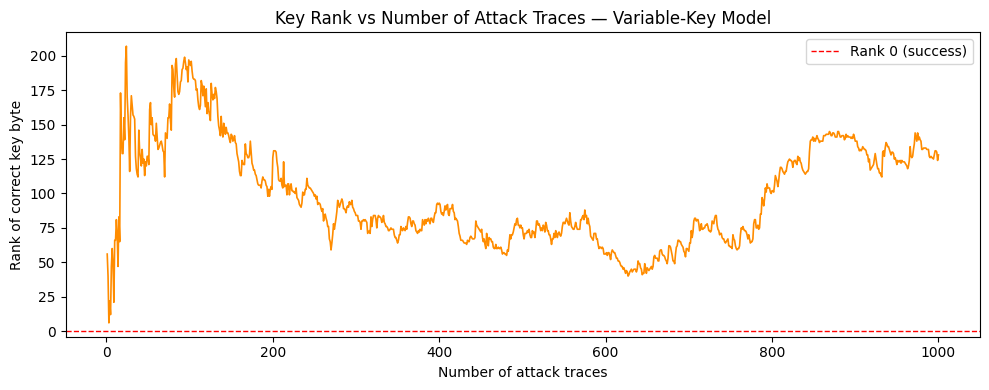

Saved: key_rank_variable.png


In [16]:
# ── Key rank plot ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, N_TRACES + 1), ranks, linewidth=1.2, color='darkorange')
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Rank 0 (success)')
ax.set_title('Key Rank vs Number of Attack Traces — Variable-Key Model')
ax.set_xlabel('Number of attack traces')
ax.set_ylabel('Rank of correct key byte')
ax.legend()
plt.tight_layout()
plt.savefig('key_rank_variable.png', dpi=150)
plt.show()
print('Saved: key_rank_variable.png')

In [17]:
# ── Comparison analysis ────────────────────────────────────
best_val_acc = max(history.history['val_accuracy'])
best_epoch   = history.history['val_accuracy'].index(best_val_acc) + 1
final_train_acc = history.history['accuracy'][-1]

print('=== Variable-Key Model Summary ===')
print(f'  Best val accuracy : {best_val_acc*100:.2f}%  (epoch {best_epoch})')
print(f'  Final train accuracy: {final_train_acc*100:.2f}%')
print(f'  Attack-set accuracy : {acc*100:.2f}%')
print(f'  Overfitting gap     : {(final_train_acc - best_val_acc)*100:.2f}%')
print()
print('Expected comparison with fixed-key model:')
print('  - Fixed-key model trains on a single device/key → tighter trace distribution')
print('    → typically higher classification accuracy (often 40–60% vs ~20–35% for variable-key)')
print('  - Variable-key model must generalise across key-dependent trace variation')
print('    → harder task; model learns key-agnostic HW features')
print('  - Key rank: fixed-key typically reaches rank 0 in <200 traces;')
print('    variable-key may require more traces or fail to fully converge')
print('    when accumulated scores are mixed across different true keys.')

=== Variable-Key Model Summary ===
  Best val accuracy : 30.52%  (epoch 16)
  Final train accuracy: 93.99%
  Attack-set accuracy : 30.30%
  Overfitting gap     : 63.46%

Expected comparison with fixed-key model:
  - Fixed-key model trains on a single device/key → tighter trace distribution
    → typically higher classification accuracy (often 40–60% vs ~20–35% for variable-key)
  - Variable-key model must generalise across key-dependent trace variation
    → harder task; model learns key-agnostic HW features
  - Key rank: fixed-key typically reaches rank 0 in <200 traces;
    variable-key may require more traces or fail to fully converge
    when accumulated scores are mixed across different true keys.


In [18]:
# ── Download outputs ───────────────────────────────────────
from google.colab import files
for f in ['model_variable_key.h5', 'training_curves_variable.png', 'key_rank_variable.png']:
    files.download(f)
    print(f'Downloaded: {f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: model_variable_key.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: training_curves_variable.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: key_rank_variable.png
